In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [ ]:

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)



print(" Dataset Loaded Successfully!")
print(f" Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f" Columns: {list(df.columns)}\n")
df.head()

 Dataset Loaded Successfully!
 Shape: 20640 rows × 10 columns
 Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(df.describe())

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(df.isnull().sum())

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

SUMMARY STATISTICS
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std  

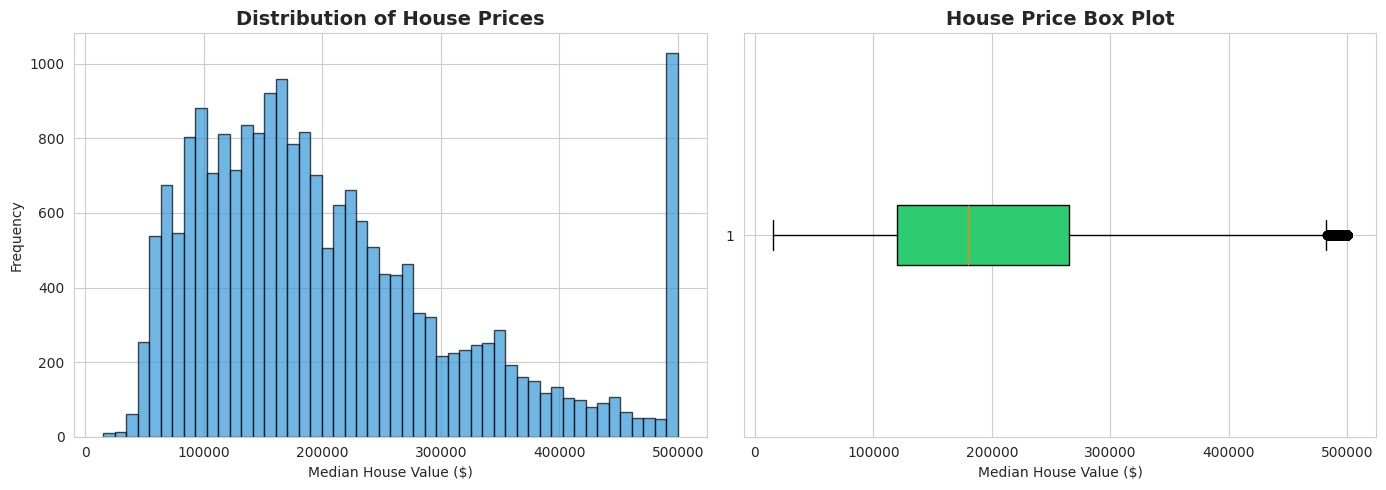

 Average Price: $206,855.82
 Median Price: $179,700.00
 Max Price: $500,001.00
 Min Price: $14,999.00


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(df['median_house_value'], bins=50, color='#3498db',
             edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Median House Value ($)')
axes[0].set_ylabel('Frequency')


axes[1].boxplot(df['median_house_value'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#2ecc71'))
axes[1].set_title('House Price Box Plot', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Median House Value ($)')

plt.tight_layout()
plt.savefig('01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Average Price: ${df['median_house_value'].mean():,.2f}")
print(f" Median Price: ${df['median_house_value'].median():,.2f}")
print(f" Max Price: ${df['median_house_value'].max():,.2f}")
print(f" Min Price: ${df['median_house_value'].min():,.2f}")

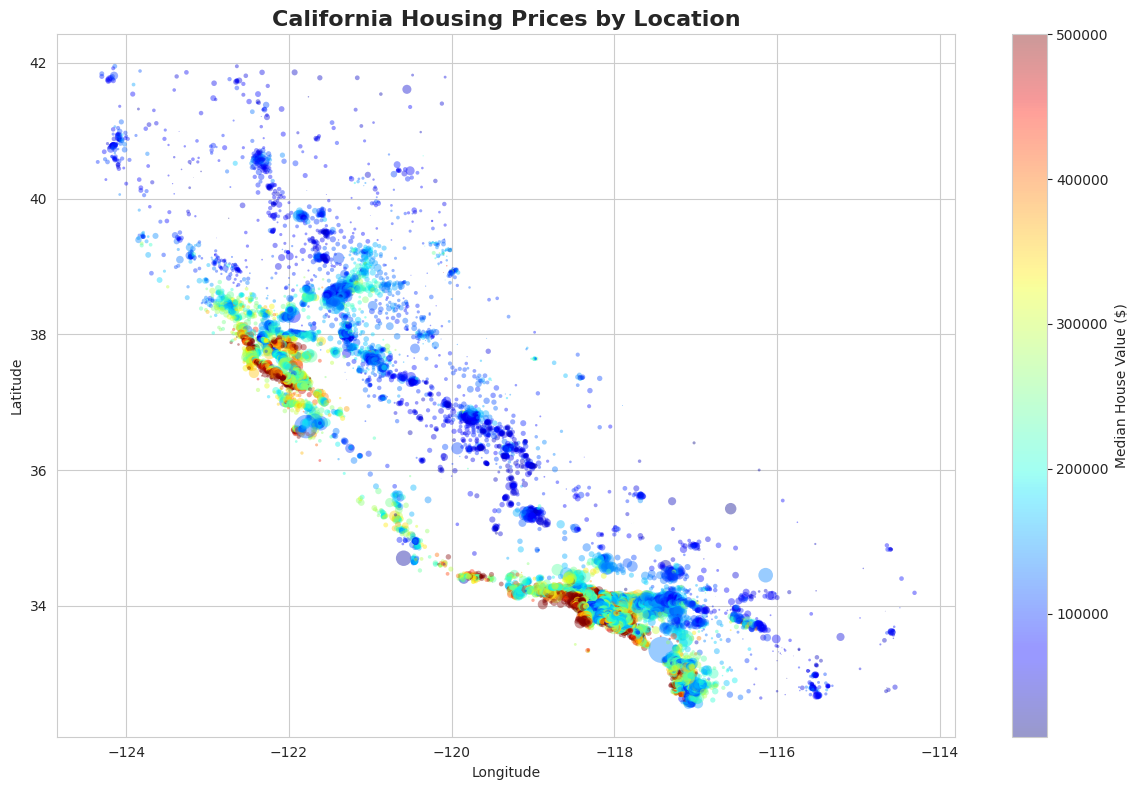

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['longitude'], df['latitude'],
                      c=df['median_house_value'], cmap='jet',
                      s=df['population']/100, alpha=0.4, edgecolors='none')
plt.colorbar(scatter, label='Median House Value ($)')
plt.title('California Housing Prices by Location',
          fontsize=16, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('02_geographical_prices.png', dpi=150, bbox_inches='tight')
plt.show()

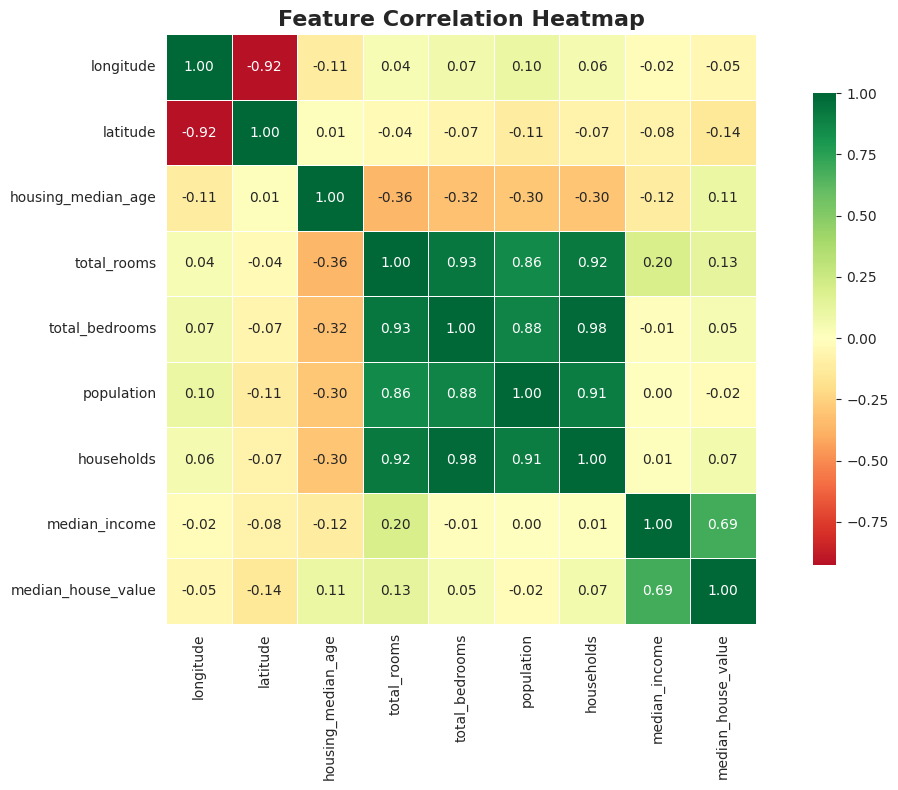


🎯 Correlation with House Price:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [ ]:

numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0,
            fmt='.2f', linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


print("\n🎯 Correlation with House Price:")
target_corr = corr_matrix['median_house_value'].sort_values(ascending=False)
print(target_corr)

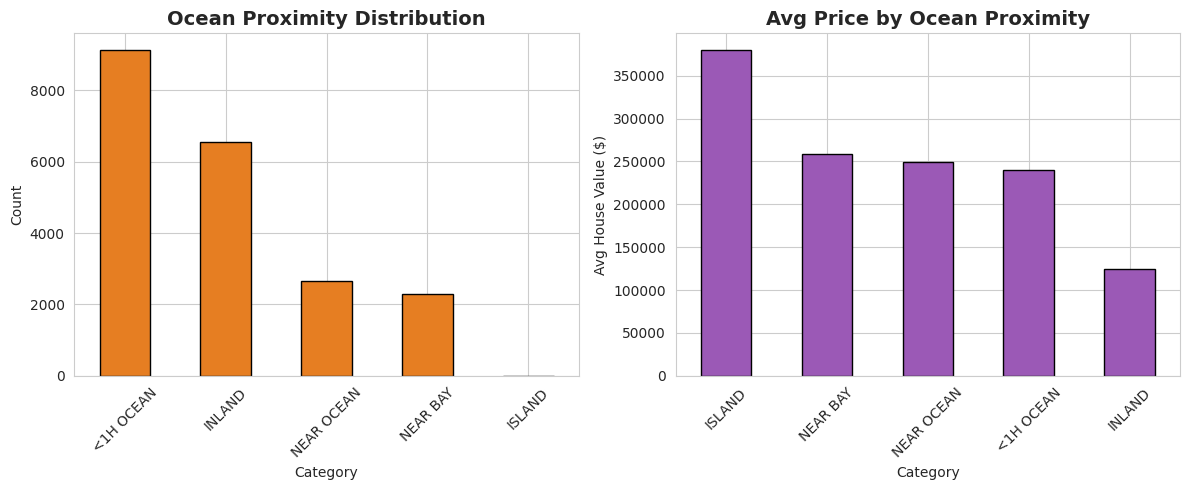

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['ocean_proximity'].value_counts().plot(kind='bar', color='#e67e22',
                                           edgecolor='black')
plt.title('Ocean Proximity Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
ocean_price = df.groupby('ocean_proximity')['median_house_value'].mean().sort_values(ascending=False)
ocean_price.plot(kind='bar', color='#9b59b6', edgecolor='black')
plt.title('Avg Price by Ocean Proximity', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Avg House Value ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('04_ocean_proximity.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

print("Missing values before:")
print(df.isnull().sum())


df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

print("\n Missing values after:")
print(df.isnull().sum())

Missing values before:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

 Missing values after:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [ ]:

df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print(" New features created:")
print(df[['rooms_per_household', 'bedrooms_per_room',
         'population_per_household']].head())

 New features created:
   rooms_per_household  bedrooms_per_room  population_per_household
0             6.984127           0.146591                  2.555556
1             6.238137           0.155797                  2.109842
2             8.288136           0.129516                  2.802260
3             5.817352           0.184458                  2.547945
4             6.281853           0.172096                  2.181467


In [ ]:

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']


numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f" Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f" Categorical columns ({len(categorical_cols)}): {categorical_cols}")

 Numerical columns (11): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
 Categorical columns (1): ['ocean_proximity']


In [ ]:

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print(" Preprocessing pipeline created!")

 Preprocessing pipeline created!


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f" Training set: {X_train.shape[0]} samples")
print(f" Testing set: {X_test.shape[0]} samples")

 Training set: 16512 samples
 Testing set: 4128 samples


In [ ]:

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}


results = []

print(" Training models...\n")
for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])


    pipeline.fit(X_train, y_train)


    y_pred = pipeline.predict(X_test)


    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R² Score': r2
    })

    print(f" {name}")
    print(f"   RMSE: ${rmse:,.2f}")
    print(f"   MAE:  ${mae:,.2f}")
    print(f"   R²:   {r2:.4f}\n")


results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False)
print("=" * 60)
print(" MODEL COMPARISON SUMMARY")
print("=" * 60)
print(results_df.to_string(index=False))

 Training models...

 Linear Regression
   RMSE: $72,668.54
   MAE:  $50,888.66
   R²:   0.5970

 Ridge Regression
   RMSE: $72,677.92
   MAE:  $50,897.58
   R²:   0.5969

 Lasso Regression
   RMSE: $72,669.36
   MAE:  $50,890.02
   R²:   0.5970

 Decision Tree
   RMSE: $71,818.76
   MAE:  $43,888.41
   R²:   0.6064

 Random Forest
   RMSE: $50,363.60
   MAE:  $32,339.10
   R²:   0.8064

 Gradient Boosting
   RMSE: $53,511.48
   MAE:  $36,491.81
   R²:   0.7815

 MODEL COMPARISON SUMMARY
            Model         RMSE          MAE  R² Score
    Random Forest 50363.603440 32339.097250  0.806435
Gradient Boosting 53511.484708 36491.813689  0.781482
    Decision Tree 71818.764143 43888.413760  0.606387
Linear Regression 72668.538379 50888.660016  0.597018
 Lasso Regression 72669.362828 50890.015723  0.597009
 Ridge Regression 72677.921474 50897.578733  0.596914


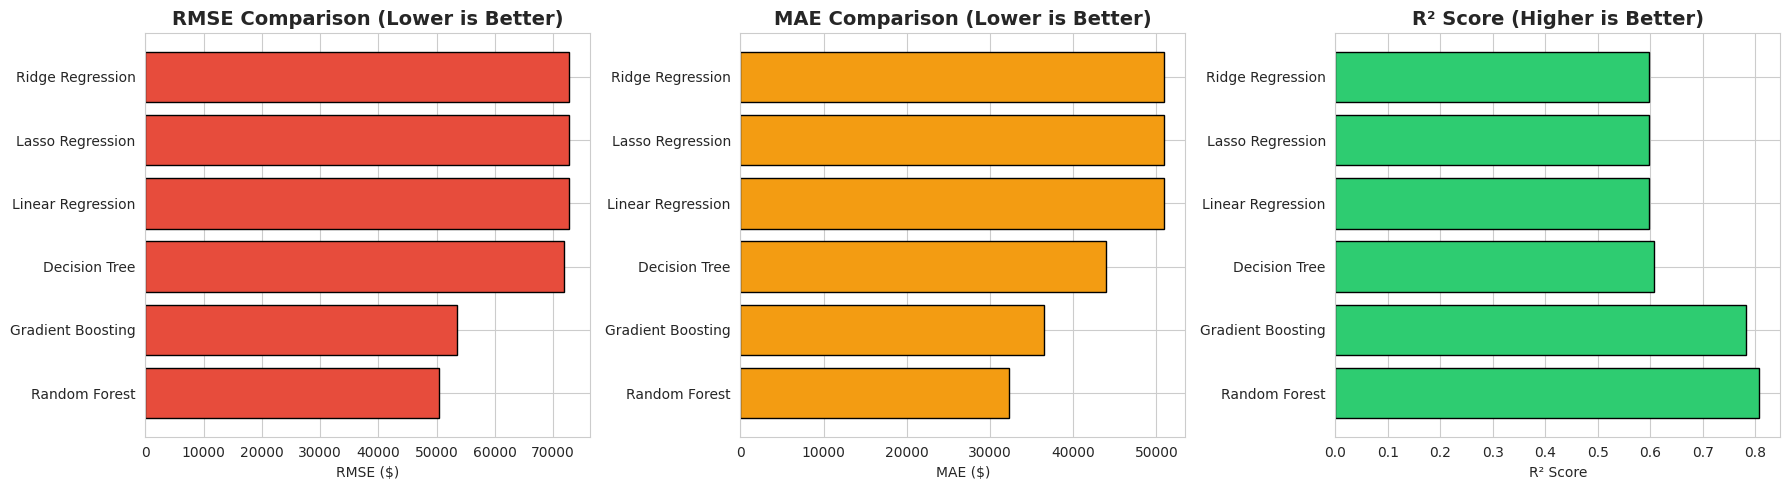

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].barh(results_df['Model'], results_df['RMSE'],
             color='#e74c3c', edgecolor='black')
axes[0].set_title('RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('RMSE ($)')


axes[1].barh(results_df['Model'], results_df['MAE'],
             color='#f39c12', edgecolor='black')
axes[1].set_title('MAE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('MAE ($)')


axes[2].barh(results_df['Model'], results_df['R² Score'],
             color='#2ecc71', edgecolor='black')
axes[2].set_title('R² Score (Higher is Better)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('R² Score')

plt.tight_layout()
plt.savefig('05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 60)
print(" BEST MODEL: RANDOM FOREST REGRESSOR")
print("=" * 60)
print(f" RMSE: ${rmse:,.2f}")
print(f" MAE:  ${mae:,.2f}")
print(f" R² Score: {r2:.4f}")
print(f" Accuracy: {r2*100:.2f}%")

 BEST MODEL: RANDOM FOREST REGRESSOR
 RMSE: $50,363.60
 MAE:  $32,339.10
 R² Score: 0.8064
 Accuracy: 80.64%


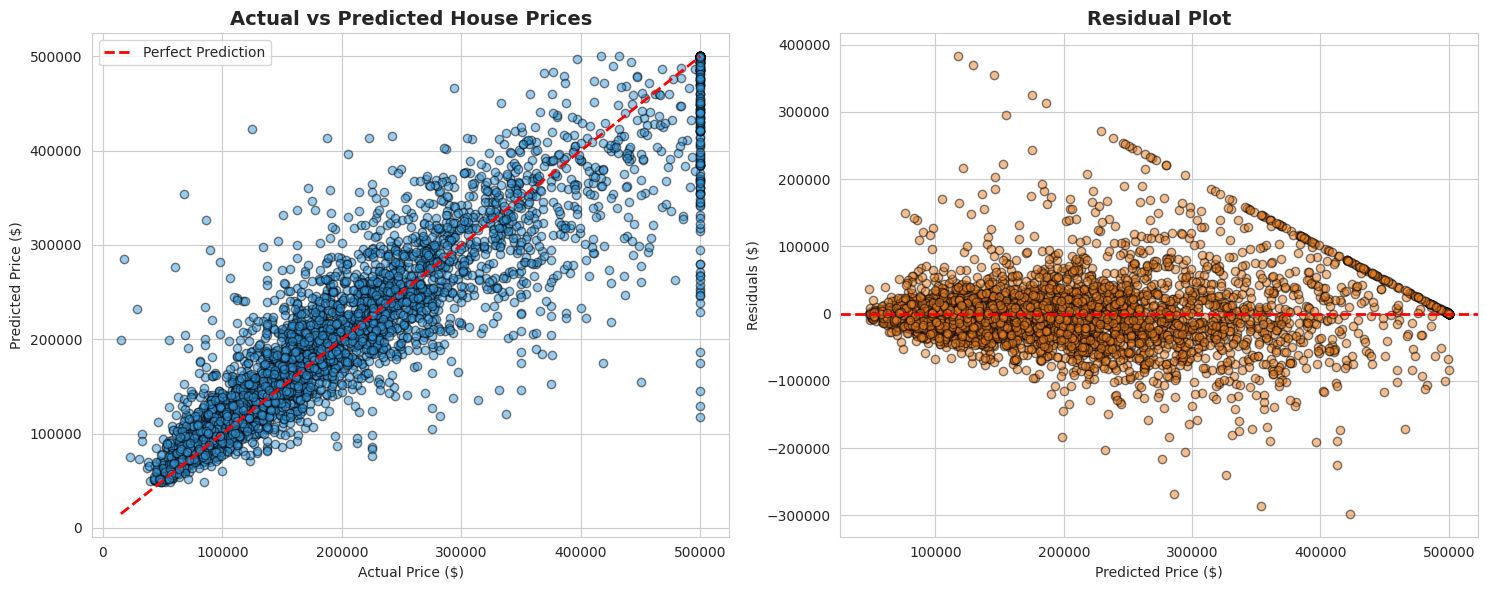

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


axes[0].scatter(y_test, y_pred, alpha=0.5, color='#3498db', edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
axes[0].legend()


residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#e67e22', edgecolors='black')
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('06_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

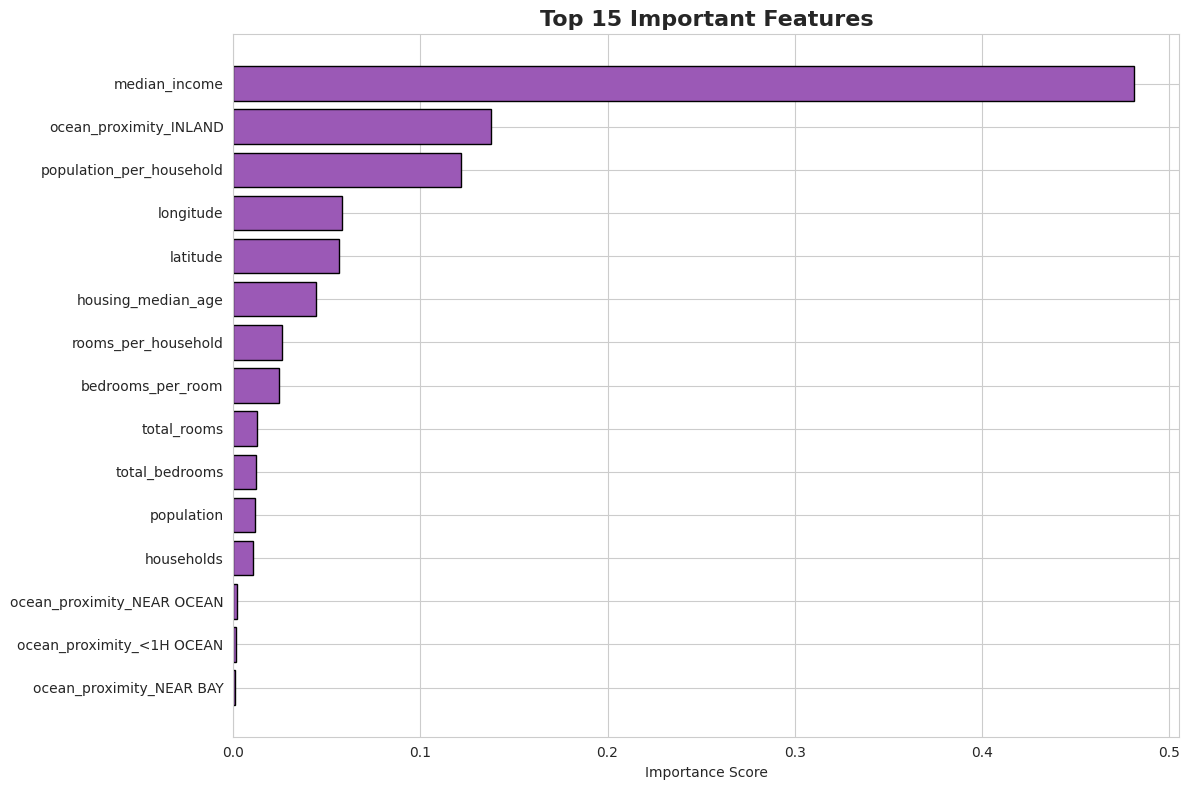


 Top 10 Most Important Features:
                 Feature  Importance
           median_income    0.481545
  ocean_proximity_INLAND    0.137497
population_per_household    0.121444
               longitude    0.057863
                latitude    0.056255
      housing_median_age    0.044235
     rooms_per_household    0.025800
       bedrooms_per_room    0.024228
             total_rooms    0.012678
          total_bedrooms    0.012304


In [ ]:

feature_names = numerical_cols.copy()
ohe_features = best_model.named_steps['preprocessor'].named_transformers_['cat']\
                        .named_steps['onehot'].get_feature_names_out(categorical_cols)
feature_names.extend(ohe_features)


importances = best_model.named_steps['model'].feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)


plt.figure(figsize=(12, 8))
top_features = feature_imp_df.head(15)
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1],
         color='#9b59b6', edgecolor='black')
plt.title('Top 15 Important Features', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Top 10 Most Important Features:")
print(feature_imp_df.head(10).to_string(index=False))

In [ ]:

new_house = pd.DataFrame({
    'longitude': [-122.23],
    'latitude': [37.88],
    'housing_median_age': [41.0],
    'total_rooms': [880.0],
    'total_bedrooms': [129.0],
    'population': [322.0],
    'households': [126.0],
    'median_income': [8.3252],
    'ocean_proximity': ['NEAR BAY'],
    'rooms_per_household': [880/126],
    'bedrooms_per_room': [129/880],
    'population_per_household': [322/126]
})

predicted_price = best_model.predict(new_house)
print(" NEW HOUSE PREDICTION")
print("=" * 50)
print(new_house.T)
print("=" * 50)
print(f" Predicted House Price: ${predicted_price[0]:,.2f}")

 NEW HOUSE PREDICTION
                                 0
longitude                  -122.23
latitude                     37.88
housing_median_age            41.0
total_rooms                  880.0
total_bedrooms               129.0
population                   322.0
households                   126.0
median_income               8.3252
ocean_proximity           NEAR BAY
rooms_per_household       6.984127
bedrooms_per_room         0.146591
population_per_household  2.555556
 Predicted House Price: $419,670.27


In [ ]:
print("=" * 70)
print("       HOUSE PRICE PREDICTION - SUMMARY REPORT ")
print("      Dataset: California Housing Prices")
print("=" * 70)

print(f"""
🔹 DATASET OVERVIEW:
   • Total Samples: {len(df):,}
   • Total Features: {df.shape[1]}
   • Target Variable: median_house_value

🔹 DATA PREPROCESSING:
   ✅ Missing values in 'total_bedrooms' filled with median
   ✅ Feature engineering: created 3 new ratio features
   ✅ Numerical features scaled using StandardScaler
   ✅ Categorical features encoded using OneHotEncoder

🔹 TRAIN-TEST SPLIT:
   • Training set: {X_train.shape[0]:,} samples (80%)
   • Testing set: {X_test.shape[0]:,} samples (20%)

🔹 MODELS COMPARED:
   • Linear Regression
   • Ridge Regression
   • Lasso Regression
   • Decision Tree
   • Random Forest ⭐ (Best)
   • Gradient Boosting

🔹 BEST MODEL PERFORMANCE (Random Forest):
   • RMSE: ${rmse:,.2f}
   • MAE:  ${mae:,.2f}
   • R² Score: {r2:.4f}
   • Model Accuracy: {r2*100:.2f}%

🔹 TOP 5 IMPORTANT FEATURES:
""")
for idx, row in feature_imp_df.head(5).iterrows():
    print(f"   • {row['Feature']}: {row['Importance']:.4f}")

print(f"""
🔹 KEY INSIGHTS:
   ✔ Median Income is the strongest predictor of house price
   ✔ Location (longitude, latitude) plays a crucial role
   ✔ Ocean proximity significantly affects house value
   ✔ Random Forest outperforms linear models due to non-linear patterns
   ✔ Model explains ~{r2*100:.0f}% of variance in house prices

🔹 CONCLUSION:
   The Random Forest model achieved excellent performance with an R² of {r2:.4f}.
   The model can reliably predict California house prices with an average
   error of ${mae:,.0f}, making it useful for real estate valuation.
""")

print("=" * 70)
print("  ✅ Task 3 Complete | All Visualizations Saved as PNG files")
print("=" * 70)

      🏠 HOUSE PRICE PREDICTION - SUMMARY REPORT 🏠
      Dataset: California Housing Prices

🔹 DATASET OVERVIEW:
   • Total Samples: 20,640
   • Total Features: 13
   • Target Variable: median_house_value

🔹 DATA PREPROCESSING:
   ✅ Missing values in 'total_bedrooms' filled with median
   ✅ Feature engineering: created 3 new ratio features
   ✅ Numerical features scaled using StandardScaler
   ✅ Categorical features encoded using OneHotEncoder

🔹 TRAIN-TEST SPLIT:
   • Training set: 16,512 samples (80%)
   • Testing set: 4,128 samples (20%)

🔹 MODELS COMPARED:
   • Linear Regression
   • Ridge Regression
   • Lasso Regression
   • Decision Tree
   • Random Forest ⭐ (Best)
   • Gradient Boosting

🔹 BEST MODEL PERFORMANCE (Random Forest):
   • RMSE: $50,363.60
   • MAE:  $32,339.10
   • R² Score: 0.8064
   • Model Accuracy: 80.64%

🔹 TOP 5 IMPORTANT FEATURES:

   • median_income: 0.4815
   • ocean_proximity_INLAND: 0.1375
   • population_per_household: 0.1214
   • longitude: 0.0579
   • l